# 쿼리 재작성 모듈 추가

이번 튜토리얼에서는 RAG 파이프라인에 **쿼리 재작성(Query Rewrite)** 기능을 추가합니다.

> 참고 문서: [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)

**학습 목표**

- 검색 품질 향상을 위한 쿼리 재작성 방법을 학습합니다.
- 재작성된 쿼리를 사용하여 더 관련성 높은 문서를 검색합니다.
- 쿼리 히스토리를 관리하는 방법을 익힙니다.

**참고**

- 이전 튜토리얼에서 확장된 내용이므로, 겹치는 부분은 간략히 설명합니다.

![langgraph-query-rewrite](assets/langgraph-query-rewrite.png)

## 환경 설정

먼저 필요한 환경 변수를 로드하고 LangSmith 추적을 설정합니다. `.env` 파일에는 사용할 LLM 제공자의 API 키가 저장되어 있어야 합니다. LangSmith 추적을 활성화하면 그래프 실행 과정을 시각적으로 디버깅할 수 있습니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다.
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-RAG")

LangChain/LangSmith API Key가 설정되지 않았습니다. 참고: https://wikidocs.net/250954


## PDF 기반 Retrieval Chain 생성

PDF 문서를 기반으로 Retrieval Chain을 생성합니다. LangGraph에서는 Retriever와 Chain을 분리하여 각 노드에서 세부 처리를 수행할 수 있습니다. 이 구조를 활용하면 검색과 생성 사이에 쿼리 재작성이나 관련성 체크 같은 중간 단계를 자연스럽게 삽입할 수 있습니다.

**사용 문서**

- 소프트웨어정책연구소(SPRi) - 2023년 12월호
- 파일명: `SPRI_AI_Brief_2023년12월호_F.pdf`

아래 코드는 PDF 문서를 로드하고 Retriever와 Chain을 생성합니다.

In [3]:
from rag.pdf import PDFRetrievalChain

# PDF 문서를 로드합니다.
pdf = PDFRetrievalChain(["data/SPRI_AI_Brief_2023년12월호_F.pdf"]).create_chain()

# retriever와 chain을 생성합니다.
pdf_retriever = pdf.retriever
pdf_chain = pdf.chain

Cache configured for multi-PDF processing
Loading PDF: data/SPRI_AI_Brief_2023년12월호_F.pdf


Successfully loaded 23 pages from: data/SPRI_AI_Brief_2023년12월호_F.pdf

Loading Summary:
- Successfully loaded: 1 files
- Failed to load: 0 files
- Total documents loaded: 23


FAISS index saved to cache


## State 정의

`State`는 그래프의 노드 간에 공유되는 상태를 정의합니다. 각 노드는 State를 입력으로 받아 처리 후 업데이트된 State를 반환하며, 이를 통해 노드 간 데이터 전달이 이루어집니다.

이전 튜토리얼과 달리 `question`을 **리스트 형식**(`List[str]`)으로 정의합니다. `add_messages` 리듀서를 사용하여 원본 질문과 재작성된 질문을 누적 저장하며, 가장 최근 질문(`[-1].content`)을 검색에 활용합니다.

아래 코드에서는 쿼리 히스토리를 관리할 수 있는 `GraphState`를 정의합니다.

In [4]:
from typing import Annotated, TypedDict, List
from langgraph.graph.message import add_messages


# GraphState 상태 정의 (TypedDict 기반 - LangGraph v1 호환)
class GraphState(TypedDict):
    question: Annotated[List[str], add_messages]  # 질문 리스트 (원본 + 재작성)
    context: Annotated[str, "Context"]  # 검색된 문서
    answer: Annotated[str, "Answer"]  # 생성된 답변
    messages: Annotated[list, add_messages]  # 대화 히스토리 (누적)
    relevance: Annotated[str, "Relevance"]  # 관련성 체크 결과

## 노드(Node) 정의

노드는 각 단계를 처리하는 함수입니다. State를 입력으로 받아 처리 후 업데이트된 State를 반환합니다. 이전 튜토리얼의 노드 구조를 유지하면서, 쿼리 재작성과 웹 검색 폴백을 포함한 전체 흐름을 구성합니다.

**노드 목록**

- `retrieve_document`: 문서를 검색합니다.
- `relevance_check`: 검색된 문서와 질문의 관련성을 평가합니다.
- `llm_answer`: 검색된 문서를 기반으로 답변을 생성합니다.
- `web_search`: 웹에서 추가 정보를 검색합니다.

**라우팅 함수**

- `is_relevant`: 조건부 엣지에서 사용되는 함수로, `relevance` 상태 값에 따라 다음 노드를 결정합니다.

아래 코드에서는 기존 노드 함수와 라우팅 함수를 정의합니다. 관련성 평가에는 `GroundednessChecker`를 사용하며, 경량 모델로 비용 효율적인 평가를 수행합니다.

In [5]:
from langchain.chat_models import init_chat_model
from langchain_teddynote.evaluator import GroundednessChecker
from langchain_teddynote.messages import messages_to_history
from langchain_teddynote.tools.tavily import TavilySearch
from rag.utils import format_docs


def retrieve_document(state: GraphState) -> GraphState:
    """문서를 검색하는 노드입니다.

    가장 최근 질문을 기반으로 관련 문서를 검색하고 포맷팅합니다.
    """
    # 가장 최근 질문을 상태에서 가져옵니다. (재작성된 질문이 있으면 그것을 사용)
    latest_question = state["question"][-1].content

    # 문서에서 검색하여 관련성 있는 문서를 찾습니다.
    retrieved_docs = pdf_retriever.invoke(latest_question)

    # 검색된 문서를 형식화합니다. (프롬프트 입력용)
    retrieved_docs = format_docs(retrieved_docs)

    # 검색된 문서를 context 키에 저장합니다.
    return {"context": retrieved_docs}


def llm_answer(state: GraphState) -> GraphState:
    """답변을 생성하는 노드입니다.

    검색된 문서와 대화 기록을 기반으로 답변을 생성합니다.
    """
    # 가장 최근 질문을 상태에서 가져옵니다.
    latest_question = state["question"][-1].content

    # 검색된 문서를 상태에서 가져옵니다.
    context = state["context"]

    # 체인을 호출하여 답변을 생성합니다.
    response = pdf_chain.invoke(
        {
            "question": latest_question,
            "context": context,
            "chat_history": messages_to_history(state["messages"]),
        }
    )

    # 생성된 답변과 메시지를 상태에 저장합니다.
    return {
        "answer": response,
        "messages": [("user", latest_question), ("assistant", response)],
    }


def relevance_check(state: GraphState) -> GraphState:
    """관련성을 체크하는 노드입니다.

    검색된 문서가 질문과 관련이 있는지 평가합니다.
    """
    # 관련성 평가기를 생성합니다.
    # When using an OpenAI key, change to models like gpt-4.1-mini, gpt-4.1-nano etc.
    question_retrieval_relevant = GroundednessChecker(
        llm=init_chat_model("claude-haiku-4-5", temperature=0),
        target="question-retrieval"
    ).create()

    # 관련성 체크를 실행합니다. ("yes" 또는 "no")
    response = question_retrieval_relevant.invoke(
        {"question": state["question"][-1].content, "context": state["context"]}
    )

    # 관련성 결과를 상태에 저장합니다.
    return {"relevance": response.score}


def is_relevant(state: GraphState) -> str:
    """조건부 엣지에서 사용되는 라우팅 함수입니다.

    관련성 여부에 따라 다음 노드를 결정합니다.
    """
    if state["relevance"] == "yes":
        return "relevant"
    else:
        return "not relevant"


def web_search(state: GraphState) -> GraphState:
    """웹 검색을 수행하는 노드입니다.

    관련성 체크 실패 시 웹에서 추가 정보를 검색합니다.
    """
    # 검색 도구 생성
    tavily_tool = TavilySearch()

    # 가장 최근 질문을 검색 쿼리로 사용합니다.
    search_query = state["question"][-1].content

    # 웹 검색 수행
    search_result = tavily_tool.search(
        query=search_query,  # 검색 쿼리
        topic="general",  # 일반 주제
        max_results=6,  # 최대 검색 결과
        format_output=True,  # 결과 포맷팅
    )

    return {"context": search_result}

## 쿼리 재작성 노드 추가

사용자 질문은 대화체이거나 모호한 표현을 포함하는 경우가 많아, 그대로 벡터 검색에 사용하면 관련 문서를 놓치는 경우가 발생합니다. 쿼리 재작성(Query Rewrite)은 원본 질문의 의도를 유지하면서 벡터 검색에 최적화된 형태로 재구성하여 검색 품질을 향상시킵니다. LLM 기반의 프롬프트 체인을 통해 키워드 최적화, 구조 개선, 명확성 향상을 수행합니다.

아래 코드에서는 쿼리 재작성 프롬프트를 정의하고 LLM 체인을 구성합니다.

In [6]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Query Rewrite 프롬프트 정의
re_write_prompt = PromptTemplate(
    template="""Reformulate the given question to enhance its effectiveness for vectorstore retrieval.

- Analyze the initial question to identify areas for improvement such as specificity, clarity, and relevance.
- Consider the context and potential keywords that would optimize retrieval.
- Maintain the intent of the original question while enhancing its structure and vocabulary.

# Steps

1. **Understand the Original Question**: Identify the core intent and any keywords.
2. **Enhance Clarity**: Simplify language and ensure the question is direct and to the point.
3. **Optimize for Retrieval**: Add or rearrange keywords for better alignment with vectorstore indexing.
4. **Review**: Ensure the improved question accurately reflects the original intent and is free of ambiguity.

# Output Format

- Provide a single, improved question.
- Do not include any introductory or explanatory text; only the reformulated question.

# Examples

**Input**:
"What are the benefits of using renewable energy sources over fossil fuels?"

**Output**:
"How do renewable energy sources compare to fossil fuels in terms of benefits?"

**Input**:
"How does climate change impact polar bear populations?"

**Output**:
"What effects does climate change have on polar bear populations?"

# Notes

- Ensure the improved question is concise and contextually relevant.
- Avoid altering the fundamental intent or meaning of the original question.


[REMEMBER] Re-written question should be in the same language as the original question.

# Here is the original question that needs to be rewritten:
{question}
""",
    input_variables=["question"],
)

# 쿼리 재작성 체인 생성 (프롬프트 -> LLM -> 문자열 파싱)
# When using an OpenAI key, change to models like gpt-4.1-mini, gpt-4.1-nano etc.
question_rewriter = (
    re_write_prompt
    | init_chat_model("claude-haiku-4-5", temperature=0)
    | StrOutputParser()
)

### 쿼리 재작성 테스트

정의한 쿼리 재작성 체인이 정상적으로 동작하는지 확인합니다. 간략하게 작성된 질문이 벡터 검색에 적합한 형태로 재구성되는지 비교합니다.

아래 코드는 테스트 질문을 재작성하고 원본과 비교합니다.

In [7]:
# 질문 재작성 테스트
question = "앤스로픽에 투자한 미국기업"

rewritten = question_rewriter.invoke({"question": question})
print(f"Original: {question}")
print(f"Rewritten: {rewritten}")

Original: 앤스로픽에 투자한 미국기업
Rewritten: 미국 기업 중 앤스로픽에 투자한 기업들은 어떤 곳들인가?


In [8]:
def query_rewrite(state: GraphState) -> GraphState:
    """쿼리를 재작성하는 노드입니다.

    검색 품질 향상을 위해 사용자 질문을 최적화된 형태로 재작성합니다.
    """
    # 가장 최근 질문을 상태에서 가져옵니다.
    latest_question = state["question"][-1].content

    # 쿼리 재작성 체인을 호출합니다.
    question_rewritten = question_rewriter.invoke({"question": latest_question})

    # 재작성된 질문을 상태에 저장합니다. (리스트에 누적)
    return {"question": question_rewritten}

## 그래프 생성

노드를 추가하고 엣지를 연결하여 쿼리 재작성이 포함된 RAG 그래프를 구성합니다. 이전 튜토리얼과 달리 **쿼리 재작성**이 시작 노드로 추가되어, 사용자 질문이 먼저 최적화된 후 검색이 수행됩니다. 관련성 체크 실패 시에는 웹 검색으로 폴백하여 무한 루프를 방지합니다.

- `START` -> `query_rewrite` -> `retrieve` -> `relevance_check`
- 관련성이 있으면(`relevant`): `llm_answer` -> `END`
- 관련성이 없으면(`not relevant`): `web_search` -> `llm_answer` -> `END`

아래 코드에서는 `START`에서 쿼리 재작성으로 시작하여, 검색, 관련성 체크, 웹 검색 또는 답변 생성으로 이어지는 그래프를 구성합니다.

In [9]:
from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.memory import MemorySaver

# 그래프 정의
workflow = StateGraph(GraphState)

# 노드 추가
workflow.add_node("retrieve", retrieve_document)
workflow.add_node("relevance_check", relevance_check)
workflow.add_node("llm_answer", llm_answer)
workflow.add_node("web_search", web_search)
workflow.add_node("query_rewrite", query_rewrite)  # 쿼리 재작성 노드 추가

# 엣지 추가
workflow.add_edge(START, "query_rewrite")  # 시작 -> 쿼리 재작성
workflow.add_edge("query_rewrite", "retrieve")  # 쿼리 재작성 -> 검색
workflow.add_edge("retrieve", "relevance_check")  # 검색 -> 관련성 체크

# 조건부 엣지 추가 (관련성에 따른 분기)
workflow.add_conditional_edges(
    "relevance_check",  # 관련성 체크 노드에서 분기
    is_relevant,  # 라우팅 함수
    {
        "relevant": "llm_answer",  # 관련성 있음 -> 답변 생성
        "not relevant": "web_search",  # 관련성 없음 -> 웹 검색
    },
)

workflow.add_edge("web_search", "llm_answer")  # 웹 검색 -> 답변 생성
workflow.add_edge("llm_answer", END)  # 답변 -> 종료

# 체크포인터 설정 (대화 기록 저장)
memory = MemorySaver()

# 그래프 컴파일
app = workflow.compile(checkpointer=memory)

### 그래프 시각화

컴파일한 그래프를 시각화합니다. 시각화를 통해 노드 간의 연결 관계와 조건부 분기 흐름을 직관적으로 확인할 수 있습니다. `query_rewrite`가 시작 노드로 설정되고, `relevance_check`에서 `relevant`와 `not relevant` 두 경로로 분기되는 구조가 표시됩니다.

아래 코드는 컴파일된 그래프를 시각화합니다.

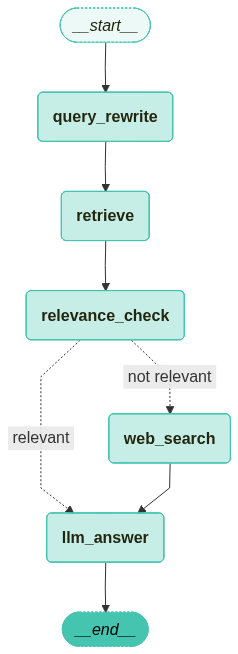

In [10]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(app)

## 그래프 실행

그래프를 실행하여 쿼리 재작성이 포함된 RAG 파이프라인을 테스트합니다. `invoke_graph`와 `stream_graph` 함수를 사용하여 각각 일괄 실행과 스트리밍 출력을 수행할 수 있습니다. 간략하게 작성된 질문을 입력하면 쿼리 재작성을 거쳐 최적화된 검색이 수행됩니다.

아래 코드에서는 간략한 질문을 입력하여 쿼리 재작성 후 검색 및 답변 생성을 테스트합니다.

In [11]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import stream_graph, invoke_graph, random_uuid

# config 설정
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": random_uuid()})

# 질문 입력 (간략한 질문 -> 쿼리 재작성으로 개선)
inputs = GraphState(question="앤스로픽 투자 금액")

# 그래프 실행
invoke_graph(app, inputs, config)


🔄 Node: query_rewrite 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
question:
앤스로픽에 대한 투자 규모 및 자금 조달 현황은 어떻게 되는가?

🔄 Node: retrieve 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
context:
<document><content>1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육
구글, 앤스로픽에 20억 달러 투자로 생성 AI 협력 강화
KEY Contents
n 구글이 앤스로픽에 최대 20억 달러 투자에 합의하고 5억 달러를 우선 투자했으며, 앤스로픽은
구글과 클라우드 서비스 사용 계약도 체결
n 3대 클라우드 사업자인 구글, 마이크로소프트, 아마존은 차세대 AI 모델의 대표 기업인
앤스로픽 및 오픈AI와 협력을 확대하는 추세
£구글, 앤스로픽에 최대 20억 달러 투자 합의 및 클라우드 서비스 제공
n 구글이 2023년 10월 27일 앤스로픽에 최대 20억 달러를 투자하기로 합의했으며, 이 중 5억
달러를 우선 투자하고 향후 15억 달러를 추가로 투자할 방침
∙ 구글은 2023년 2월 앤스로픽에 이미 5억 5,000만 달러를 투자한 바 있으며, 아마존도 지난 9월
앤스로픽에 최대 40억 달러의 투자 계획을 공개
∙ 한편, 2023년 11월 8일 블룸버그 보도에 따르면 앤스로픽은 구글의 클라우드 서비스 사용을 위해
4년간 30억 달러 규모의 계약을 체결
∙ 오픈AI 창업자 그룹의 일원이었던 다리오(Dario Amodei)와 다니엘라 아모데이(Daniela Amodei)
남매가 2021년 설립한 앤스로픽은 챗GPT의 대항마 ‘클로드(Claude)’ LLM을 개발
n 아마존과 구글의 앤스로픽 투자에 앞서, 마이크로소프트는 차세대 AI 모델의 대표 주자인 오픈
AI와 협력을 확대
∙ 마이크로소프트는 오픈AI에 앞서 투자한 30억 달러에 더해 2023년 1월 추가로 100억 달러를
투자하기로


🔄 Node: relevance_check 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
relevance:
yes



🔄 Node: llm_answer 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
answer:
앤스로픽에 대한 투자 규모 및 자금 조달 현황은 다음과 같다. 구글은 2023년 10월 27일 최대 20억 달러 투자를 합의했으며, 이 중 5억 달러를 우선 투자했고, 향후 15억 달러를 추가 투자할 계획이다. 또한 구글은 2023년 2월에 이미 5억 5,000만 달러를 투자한 바 있다. 아마존도 2023년 9월 앤스로픽에 최대 40억 달러 투자 계획을 공개했다. 한편, 앤스로픽은 구글과 4년간 30억 달러 규모의 클라우드 서비스 계약을 체결했다.

**Source**
- data/SPRI_AI_Brief_2023년12월호_F.pdf (p.14, p.10)
('user', '앤스로픽에 대한 투자 규모 및 자금 조달 현황은 어떻게 되는가?')
('assistant', '앤스로픽에 대한 투자 규모 및 자금 조달 현황은 다음과 같다. 구글은 2023년 10월 27일 최대 20억 달러 투자를 합의했으며, 이 중 5억 달러를 우선 투자했고, 향후 15억 달러를 추가 투자할 계획이다. 또한 구글은 2023년 2월에 이미 5억 5,000만 달러를 투자한 바 있다. 아마존도 2023년 9월 앤스로픽에 최대 40억 달러 투자 계획을 공개했다. 한편, 앤스로픽은 구글과 4년간 30억 달러 규모의 클라우드 서비스 계약을 체결했다.\n\n**Source**\n- data/SPRI_AI_Brief_2023년12월호_F.pdf (p.14, p.10)')


In [12]:
# 그래프 스트리밍 실행
stream_graph(app, inputs, config, node_names=["query_rewrite", "llm_answer"])


🔄 Node: query_rewrite 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 


앤스로픽에

 대한 투자 금

액은

얼마인가?

...

 (

p

.

14

)

### 결과 확인

그래프 실행 후 최종 상태를 확인합니다. `get_state` 메서드를 사용하면 현재 체크포인트에 저장된 모든 상태 값을 조회할 수 있습니다. 원본 질문과 재작성된 질문을 비교하고, 최종 답변을 확인합니다.

아래 코드는 최종 상태에서 원본 질문, 재작성된 질문, 답변을 출력합니다.

In [13]:
# 최종 출력 확인
outputs = app.get_state(config).values

print(f'Original Question: {outputs["question"][0].content}')
print(f'Rewritten Question: {outputs["question"][-1].content}')
print("===" * 20)
print(f'Answer:\n{outputs["answer"]}')

Original Question: 앤스로픽 투자 금액
Rewritten Question: 앤스로픽에 대한 투자 금액은 얼마인가?
Answer:
구글은 앤스로픽에 최대 20억 달러를 투자하기로 합의했으며, 이 중 5억 달러를 우선 투자했고 향후 15억 달러를 추가 투자할 계획입니다. 또한, 2023년 2월에 이미 5억 5,000만 달러를 투자한 바 있습니다.

**Source**  
- data/SPRI_AI_Brief_2023년12월호_F.pdf (p.14)


## 정리

이 튜토리얼에서는 RAG 파이프라인에 **쿼리 재작성** 기능을 추가했습니다.

### 핵심 개념

1. **Query Rewrite**: 사용자 질문을 벡터 검색에 최적화된 형태로 재작성합니다.
2. **쿼리 히스토리**: 리스트 형식으로 원본 및 재작성된 쿼리를 관리합니다.
3. **검색 품질 향상**: 재작성된 쿼리로 더 관련성 높은 문서를 검색합니다.

### 다음 단계

다음 튜토리얼에서는 **Agentic RAG**를 구현하여 에이전트가 검색 도구 사용 여부를 스스로 결정하는 방법을 학습합니다.